### Imports

In [1]:
import json
from datetime import datetime
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from c50py import C5Classifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

### Dataset

In [2]:
dataset = pd.read_csv(
    "../dataset/datasets/full_v4_pca_yeo-johnson_2026-10-01_17-12-09.csv"
)

### Prepare predictors, target, and subject groups


In [ ]:
X = dataset.drop(columns=["Activity", "subject"])
y_text = dataset["Activity"]
groups = dataset["subject"]

### Encode target labels

In [4]:
le = LabelEncoder()
y = pd.Series(
    le.fit_transform(y_text),
    index=y_text.index,
    name="Activity",
)

### Subject-safe train/test split 

In [5]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.3,
    random_state=69,
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]
groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Training subjects:", sorted(groups_train.unique()))
print("Test subjects:", sorted(groups_test.unique()))
print("Subject overlap:", set(groups_train.unique()) & set(groups_test.unique()))


Training subjects: [np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(17), np.int64(18), np.int64(19), np.int64(21), np.int64(23), np.int64(24), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
Test subjects: [np.int64(3), np.int64(9), np.int64(14), np.int64(15), np.int64(16), np.int64(20), np.int64(22), np.int64(25), np.int64(26)]
Subject overlap: set()


### Train C5.0

In [6]:
c5_model = C5Classifier()
c5_model.fit(X_train, y_train)

,trials,1
,min_samples_split,2
,min_samples_leaf,2
,pruning,True
,cf,0.25
,global_pruning,True
,random_state,None
,feature_names,None
,categorical_features,None
,infer_categorical,True
,int_as_categorical,False


### Predict

In [7]:
y_pred = c5_model.predict(X_test)

### Evaluate using the original activity names

In [8]:
labels = list(range(len(le.classes_)))
class_names = le.classes_.tolist()

report = classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    labels=labels,
    normalize="true",
).round(4).tolist()

### Logging

In [9]:
model_name = "c5.0_v1 Decision Tree"
dataset_name = "dataset"
note = "N/A"

report = classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    labels=labels,
    normalize="true",
).round(4).tolist()

# Capture available C5.0 parameters
c5_params = {}
if hasattr(c5_model, "get_params"):
    c5_params = c5_model.get_params()

record = {
    "timestamp": datetime.now().isoformat(),
    "dataset": dataset_name,
    "model": model_name,
    "note": note or "N/A",
    "overall_accuracy": float(accuracy_score(y_test, y_pred)),
    "macro_f1": float(report["macro avg"]["f1-score"]),
    "classes": class_names,
    "confusion_matrix_percent": cm_normalized,
    "classification_report": report,
    "params": {
        "learning_rate": None,
        "max_depth": c5_params.get("max_depth"),
        "n_estimators": None,
        "num_round": None,
        "subsample": None,
        "colsample_bytree": None,
        "min_child_weight": None,
        "c5_specific": c5_params,
    },
}

with open("results.jsonl", "a", encoding="utf-8") as f:
    f.write(json.dumps(record) + "\n")

print(
    f"Logged {record['model']} on dataset "
    f"'{record['dataset']}' to results.jsonl"
)

Logged c5.0_v1 Decision Tree on dataset 'dataset' to results.jsonl


Confusion Matrix:
                            Predicted: LAYING  Predicted: SITTING  \
Actual: LAYING                            470                 105   
Actual: SITTING                            70                 333   
Actual: STANDING                           15                 138   
Actual: WALKING                             1                   0   
Actual: WALKING_DOWNSTAIRS                  1                   0   
Actual: WALKING_UPSTAIRS                    7                   1   

                            Predicted: STANDING  Predicted: WALKING  \
Actual: LAYING                               19                   0   
Actual: SITTING                             150                   0   
Actual: STANDING                            428                   0   
Actual: WALKING                               0                 321   
Actual: WALKING_DOWNSTAIRS                    0                  58   
Actual: WALKING_UPSTAIRS                      1                  18   



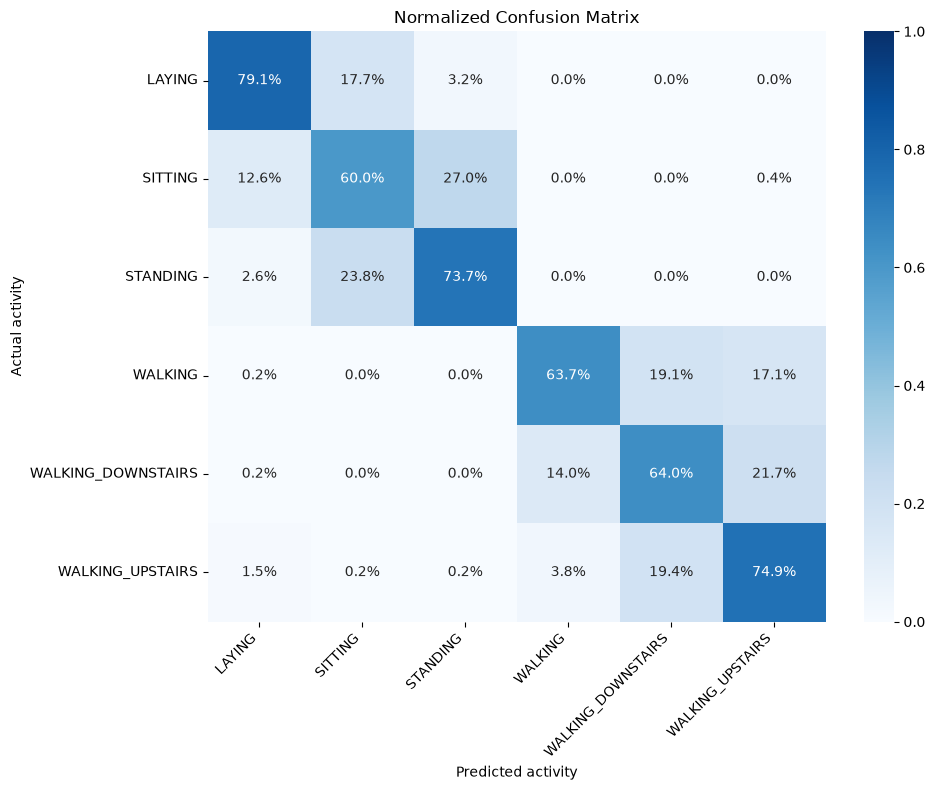

In [10]:
# Raw confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)

print("Confusion Matrix:")
print(
    pd.DataFrame(
        cm,
        index=[f"Actual: {name}" for name in class_names],
        columns=[f"Predicted: {name}" for name in class_names],
    )
)

# Normalized confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted activity")
plt.ylabel("Actual activity")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()